In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Basic_functions as bf

from sklearn.preprocessing import StandardScaler, RobustScaler
import lightgbm as lgbm
from lightgbm import early_stopping

In [46]:
chars_set = set(["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z", "æ", "ø", "å", " "])
test = "I am a Dwarf a.nd i'm digging a hoooool!\ndigg! dig! hol!"
test = test.replace("\n", " ")
test = "".join(ch for ch in test.lower() if ch in chars_set)

In [47]:
test.strip()

'i am a dwarf and im digging a hoooool digg dig hol'

In [64]:
chars = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z", "æ", "ø", "å", " "]
data, labels = bf.read_files("Speeches", chars)

In [2]:
word_dict = bf.count_words("Speeches")

In [6]:
len(word_dict.keys())

175099

In [15]:
test = np.genfromtxt("word_counts.txt", dtype=str)

In [13]:
word_list = list(word_dict.keys())
count_list = list(word_dict.values())
np.savetxt("word_counts.txt", np.array([word_list, count_list]).T, fmt="%s")

In [27]:
sort_idx = np.argsort(count_list)[::-1]
sorted_words = np.array(word_list)[sort_idx]
sorted_counts = np.array(count_list)[sort_idx]

In [22]:
np.savetxt("word_counts.txt", np.array([sorted_words, sorted_counts]).T, fmt="%s")

In [28]:
list(sorted_words[:2005])

[np.str_('og'),
 np.str_('at'),
 np.str_('i'),
 np.str_('det'),
 np.str_('er'),
 np.str_('vi'),
 np.str_('for'),
 np.str_('til'),
 np.str_('en'),
 np.str_('der'),
 np.str_('den'),
 np.str_('som'),
 np.str_('ikke'),
 np.str_('de'),
 np.str_('af'),
 np.str_('har'),
 np.str_('med'),
 np.str_('på'),
 np.str_('jeg'),
 np.str_('om'),
 np.str_('et'),
 np.str_('men'),
 np.str_('kan'),
 np.str_('skal'),
 np.str_('så'),
 np.str_('os'),
 np.str_('var'),
 np.str_('sig'),
 np.str_('vil'),
 np.str_('han'),
 np.str_('man'),
 np.str_('være'),
 np.str_('ved'),
 np.str_('fra'),
 np.str_('vores'),
 np.str_('alle'),
 np.str_('hvor'),
 np.str_('også'),
 np.str_('eller'),
 np.str_('her'),
 np.str_('dem'),
 np.str_('selv'),
 np.str_('nu'),
 np.str_('paa'),
 np.str_('hvad'),
 np.str_('da'),
 np.str_('når'),
 np.str_('over'),
 np.str_('noget'),
 np.str_('du'),
 np.str_('dag'),
 np.str_('mig'),
 np.str_('mange'),
 np.str_('saa'),
 np.str_('deres'),
 np.str_('have'),
 np.str_('end'),
 np.str_('mere'),
 np.str_('

In [29]:
data, labels = bf.read_files("Speeches", list(sorted_words[:2005]))

In [68]:
data = np.genfromtxt("word_frequencies_2000.txt")

In [76]:
data = np.array(data)
labels = np.array(labels)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = data_scaled[labels > 2020]
labels_scaled = labels[labels > 2020]
labels_scaled = labels_scaled

In [77]:
params = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 20,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

In [78]:
train_data = data_scaled[:int(0.8*len(data_scaled))]
train_labels = labels_scaled[:int(0.8*len(labels_scaled))]
val_data = data_scaled[int(0.8*len(data_scaled)):int(0.95*len(data_scaled))]
val_labels = labels_scaled[int(0.8*len(labels_scaled)):int(0.95*len(labels_scaled))]
test_data = data_scaled[int(0.95*len(data_scaled)):]
test_labels = labels_scaled[int(0.95*len(labels_scaled)):]
lgb_train = lgbm.Dataset(train_data, label=train_labels)
lgb_val = lgbm.Dataset(val_data, label=val_labels, reference=lgb_train)
model = lgbm.train(params, lgb_train, valid_sets=[lgb_train, lgb_val], num_boost_round=1000, callbacks=[early_stopping(50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[313]	training's l2: 0.0615571	valid_1's l2: 1.80699


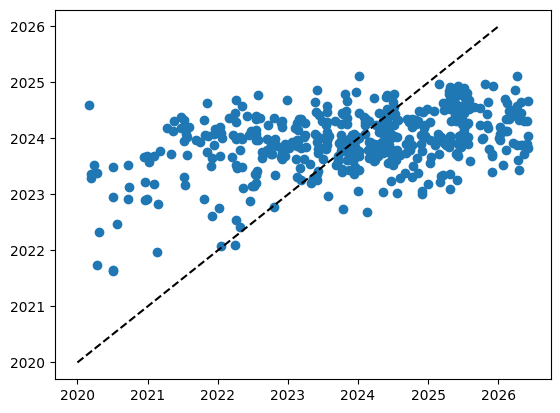

In [80]:
plt.plot(val_labels, model.predict(val_data), "o")
plt.plot([2020, 2026], [2020, 2026], "k--")
#plt.xlim(2018, 2027)
#plt.ylim(2018, 2027)

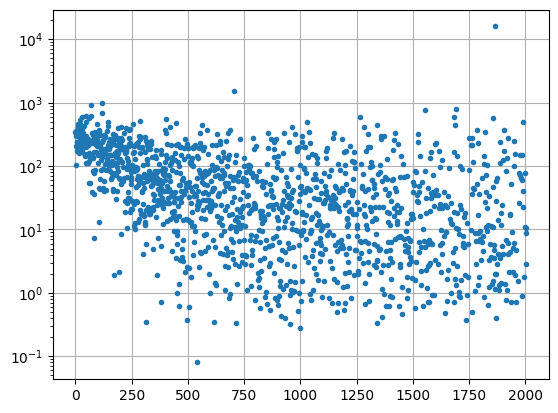

In [88]:
plt.plot(model.feature_importance(importance_type="gain"), ".")
plt.yscale("log")
plt.grid()

In [6]:
test_speech = open("test.txt", "r").read()
test_speech_data = bf.convert_to_data(test_speech, chars)

In [7]:
model.predict([test_speech_data])

array([23.64302537])

In [27]:
np.mean(labels)

np.float64(1993.833620919064)

In [13]:
model.predict(test_data)

array([ -43.45949295,  -55.31170448,  -41.86957323,  -61.60097825,
        -32.50387642,   15.8978201 ,   26.50305802,   10.3817101 ,
         23.54973952,  -75.1508267 ,   25.89405299,   24.26719992,
         19.27546165,   21.88278845,   18.91638827,   23.53752988,
         31.7233499 ,   15.75853587, -122.08753968,   23.71300754,
         18.44896129,   23.31839616,   16.0102125 ,   21.19210292,
          5.51567146,   21.60828215,   25.42972843,   25.01657786,
         26.29343679,   23.92454995,   26.18655454,   23.69506529,
         10.65264355,   24.38383314,   10.64566627,   23.69690549,
         23.34904098,   16.09072231,   22.8684581 ,   23.79729154,
         20.85383015,   24.04316806,   24.12764137,   23.89440954,
         16.31669968,   10.35891703,   20.33592943,   19.16334952,
         20.64140921,   24.11454124,   28.26948276,   25.23077268,
         26.1321853 ,   24.29464827,   17.40945138,   18.31327158,
          7.73357783,   16.13740252,   18.38265718,   15.15270

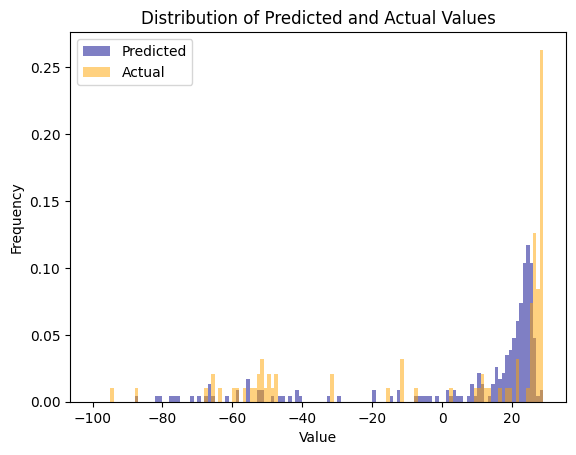

In [25]:
plt.hist(model.predict(test_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(test_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()

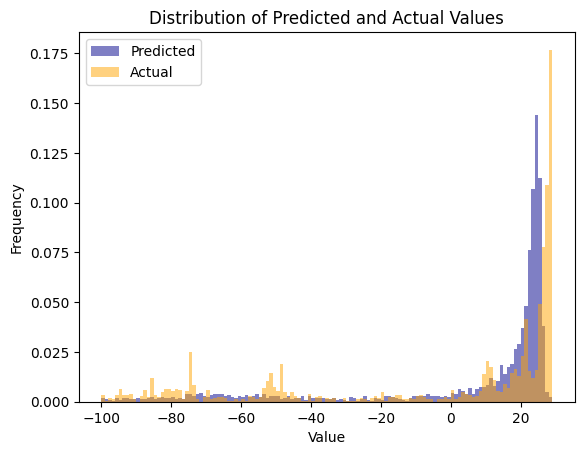

In [26]:
plt.hist(model.predict(train_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(train_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()